
## Limpieza de datos para pobreza_laboral_jefatura_sexo.csv obtenido de: Cuadro_de_indicadores_ITLP_4T2024.xlsx

In [1]:
import pandas as pd
import numpy as np

#declaramos los nombres de las columnas que nos interesan
columnas = [
    'anio', 'trimestre', 'pobreza_nal', 'pobreza_hombres', 'pobreza_mujeres', 
    'columna_vacia', 'ingreso_nal', 'ingreso_hombres', 'ingreso_mujeres'
]

In [ ]:
#Cargar el CSV con solo los datos que nos interesan
df = pd.read_csv('../data/pobreza_laboral_jefaura_sexo.csv', skiprows=7, names=columnas)

In [4]:
#Eliminar las columnas vacías
df = df.drop(columns=['columna_vacia'])
#Rellenar los años
df['anio'] = df['anio'].ffill()
#Eliminar la anomalía provocada por el COVID 19
df = df.replace({'ND': np.nan, 'll*': 'II'})

In [5]:
#Limpieza vectorial de caracteres inválidos o que estorban
columnas_ingreso = ['ingreso_nal', 'ingreso_hombres', 'ingreso_mujeres']
for col in columnas_ingreso:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False)\
                                 .str.replace(',', '', regex=False)\
                                 .str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
#Nos aseguramos que los porcentajes de pobreza sean de tipo flotantes
columnas_pobreza = ['pobreza_nal', 'pobreza_hombres', 'pobreza_mujeres']
for col in columnas_pobreza:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
# Mostramos las primeras 10 filas de nuestro df
df.head(10)

,anio,trimestre,pobreza_nal,pobreza_hombres,pobreza_mujeres,ingreso_nal,ingreso_hombres,ingreso_mujeres
0,2005.0,I,38.1,36.2,45.2,2605.92,2700.40,2268.47
1,2005.0,II,38.8,36.4,46.7,2608.59,2710.83,2285.59
2,2005.0,III,38.1,35.5,46.8,2641.13,2747.83,2271.76
3,2005.0,IV,36.6,34.4,43.8,2729.02,2838.33,2357.85
4,2006.0,I,36.2,34.0,43.7,2722.13,2821.10,2386.72
5,2006.0,II,35.2,32.8,42.8,2783.78,2894.60,2423.35
6,2006.0,III,35.8,33.5,43.2,2828.56,2945.92,2432.37
7,2006.0,IV,36.3,34.2,43.3,2772.54,2886.37,2388.75
8,2007.0,I,36.5,34.3,43.3,2768.23,2874.17,2416.61
9,2007.0,II,34.7,32.4,41.7,2833.26,2944.79,2479.18


In [8]:
#última verificación de los tipos de datos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   anio             80 non-null     float64
 1   trimestre        80 non-null     object 
 2   pobreza_nal      79 non-null     float64
 3   pobreza_hombres  79 non-null     float64
 4   pobreza_mujeres  79 non-null     float64
 5   ingreso_nal      79 non-null     float64
 6   ingreso_hombres  79 non-null     float64
 7   ingreso_mujeres  79 non-null     float64
dtypes: float64(7), object(1)
memory usage: 5.1+ KB
None


In [10]:
df.to_csv('../data/clean_data/pobreza_laboral_jefatura_sexo_clean.csv', index=False)

# Visualizacion

In [11]:
# Importamos las bibliotecas necesarias de visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Hacemos un mapeo de los trimestres para que tengan formato date
mapping = {'I': '01-01', 'II': '04-01', 'III': '07-01', 'IV': '10-01'}

# Convertimos anio a int y luego a fecha
df['fecha'] = pd.to_datetime(df['anio'].astype(int).astype(str) + '-' + df['trimestre'].map(mapping))

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

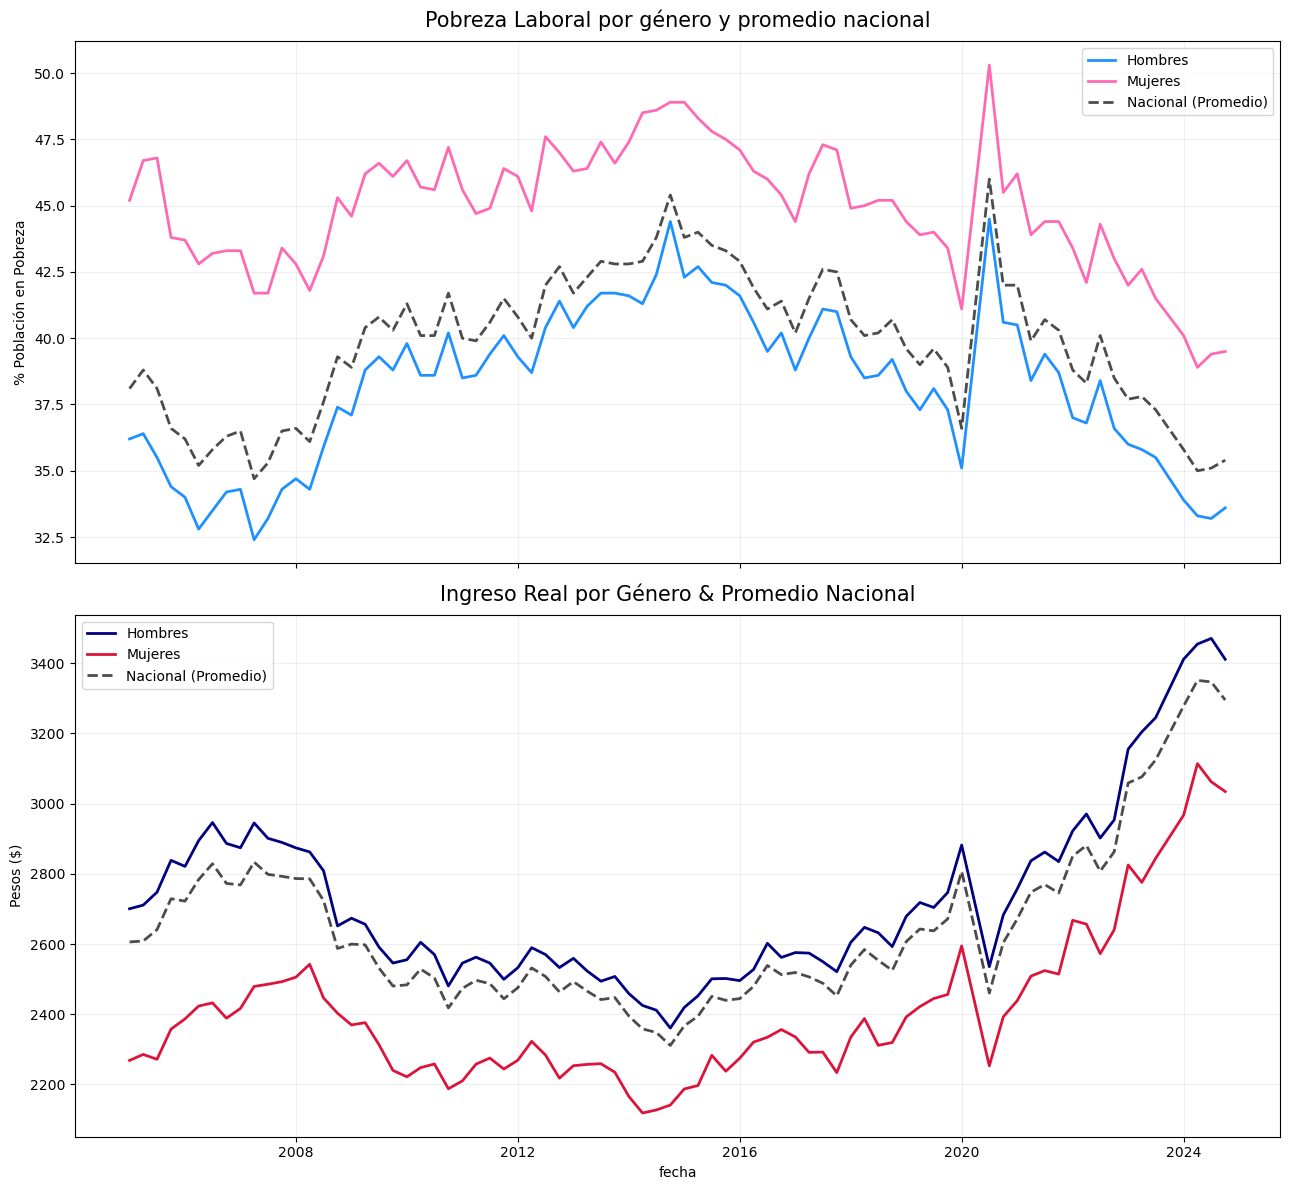

In [17]:
# Configuramos los subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 12), sharex=True)

# --- GRÁFICA DE POBREZA ---
# Líneas de género
sns.lineplot(data=df, x='fecha', y='pobreza_hombres', ax=ax1, color='dodgerblue', label='Hombres', linewidth=2)
sns.lineplot(data=df, x='fecha', y='pobreza_mujeres', ax=ax1, color='hotpink', label='Mujeres', linewidth=2)

# Línea Nacional (Referencia)
sns.lineplot(data=df, x='fecha', y='pobreza_nal', ax=ax1, color='black', label='Nacional (Promedio)', 
             linestyle='--', linewidth=2, alpha=0.7)

ax1.set_title('Pobreza Laboral por género y promedio nacional', fontsize=15, pad=10)
ax1.set_ylabel('% Población en Pobreza')
ax1.grid(True, alpha=0.2)
ax1.legend()

# --- GRÁFICA DE INGRESO ---
# Líneas de género
sns.lineplot(data=df, x='fecha', y='ingreso_hombres', ax=ax2, color='navy', label='Hombres', linewidth=2)
sns.lineplot(data=df, x='fecha', y='ingreso_mujeres', ax=ax2, color='crimson', label='Mujeres', linewidth=2)

# Línea Nacional (Referencia)
sns.lineplot(data=df, x='fecha', y='ingreso_nal', ax=ax2, color='black', label='Nacional (Promedio)', 
             linestyle='--', linewidth=2, alpha=0.7)

ax2.set_title('Ingreso Real por Género & Promedio Nacional', fontsize=15, pad=10)
ax2.set_ylabel('Pesos ($)')
ax2.grid(True, alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

Observamos que en ambas graficas el promedio nacional (la linea punteada negra) historicamente no solo se acerca, sino que se asemeja mucho mas a la linea azul (la de los hombres), debido a que ellos tienen mayor peso en la fuerza laboral formal, mientras que la linea de las mujeres queda aislada por debajo.

Es importante notar que si bien la disparidad de ingresos es relativamente estrecha, la disparidad de pobreza es mas grande, pues el porcentaje de mujeres en pobreza es notablemente mayor.

Si bien las graficas nos permiten observar como ha evolucionado tanto los ingresos como la pobreza agregada por genero, no ilustra claramente como ha evolucionado la brecha salarial, por ello, calcularemos la proporcion que nos dira *"Por cada 100 pesos que gana un hombre, ¿cuántos gana una mujer?"*

Esta proporcion se calculara bajo la siguiente formula matematica:
$$Proporcion = \dfrac{\text{Ingreso mujeres}}{\text{Ingreso Hombres}}$$

In [14]:
# Calculamos la proporción (multiplicamos por 100 para verlo como porcentaje)
df['proporcion_salarial'] = (df['ingreso_mujeres'] / df['ingreso_hombres']) * 100

# También podemos calcular el promedio histórico para tener una referencia
promedio_historico = df['proporcion_salarial'].mean()

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


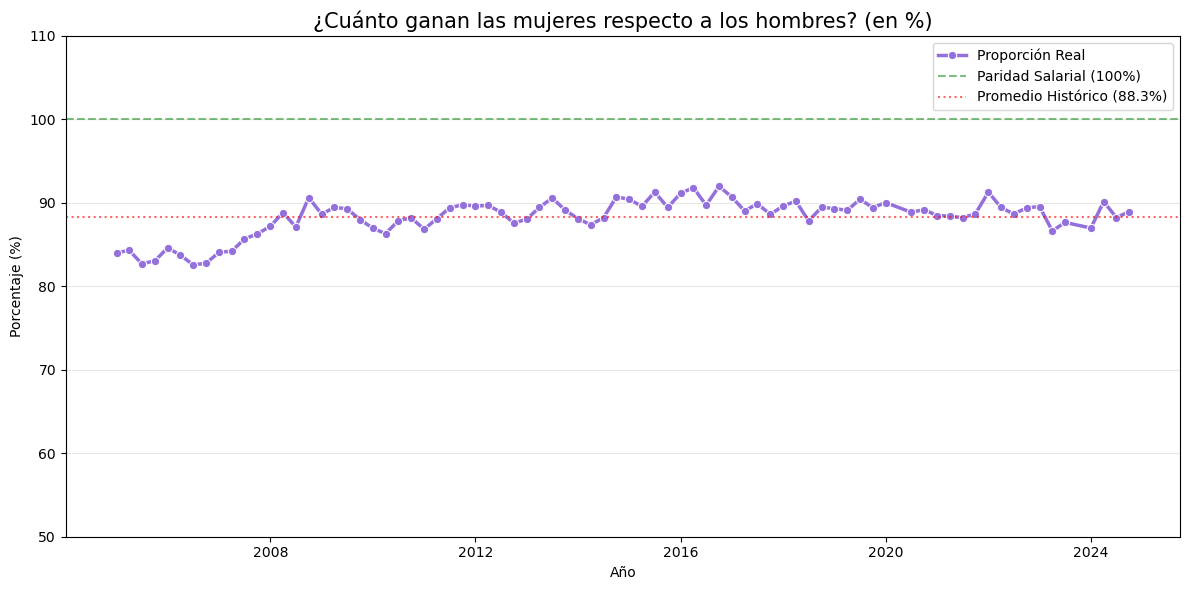

In [15]:
# Graficamos la evolucion de la equidad
plt.figure(figsize=(12, 6))

# Graficamos la proporción
sns.lineplot(data=df, x='fecha', y='proporcion_salarial', 
             color='mediumpurple', marker='o', linewidth=2.5, label='Proporción Real')

# Añadimos una línea horizontal en el 100% (Paridad Total)
plt.axhline(100, color='green', linestyle='--', alpha=0.5, label='Paridad Salarial (100%)')

# Añadimos una línea con el promedio histórico
plt.axhline(promedio_historico, color='red', linestyle=':', alpha=0.6, 
            label=f'Promedio Histórico ({promedio_historico:.1f}%)')

plt.title('¿Cuánto ganan las mujeres respecto a los hombres? (en %)', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Año')
plt.ylim(50, 110) # Ajustamos el eje Y para ver mejor la variación
plt.grid(True, axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()